# generate_ancillary 官方数据测试

本 Notebook 使用官方测试数据，调用迁移后的 `generate_ancillary` 算法，并绘图对比验证适配算法结果、 `kgo` 结果与原算法结果一致。

## 1. 环境准备与全局参数

In [1]:
from pathlib import Path
import json
import sys

import meteva_base as meb
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (15, 4.5)

PROJECT_ROOT = Path.cwd().resolve().parent
ROOT_DIR = Path.cwd().resolve().parents[1]
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from generate_ancillary.src.generate_ancillary import (
    THRESHOLDS_DICT,
    GenerateOrographyBandAncils,
)

TEST_DATA_ROOT = PROJECT_ROOT / "test_data" / "official_test_generate_ancillary"
BASIC_DIR = TEST_DATA_ROOT / "basic"
NO_LANDMASK_DIR = TEST_DATA_ROOT / "basic_no_landsea_mask"

d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. 数据读取与工具函数

In [2]:
def load_primary_dataarray(path: Path) -> xr.DataArray:
    """读取 NetCDF 文件中的主变量。"""
    dataset = xr.open_dataset(path, decode_timedelta=False)
    for name, data_array in dataset.data_vars.items():
        if "bnds" not in name and name != "lambert_azimuthal_equal_area":
            return data_array
    raise ValueError(f"未在 {path} 中找到主数据变量。")


def load_thresholds_from_json(path: Path) -> dict:
    """读取 JSON 格式的地形带定义。"""
    with open(path, "r", encoding="utf-8") as infile:
        return json.load(infile)


def common_limits(*arrays) -> tuple[float, float]:
    """为多张结果图生成统一色标范围。"""
    stacked = [np.asarray(item, dtype=np.float32) for item in arrays]
    return float(np.nanmin(stacked)), float(np.nanmax(stacked))


def describe_bands(data: xr.DataArray) -> None:
    """打印当前结果中的地形带点值与上下界。"""
    summary = []
    for idx, point in enumerate(data.coords["level"].values):
        lower = data.coords["level_lower_bound"].values[idx]
        upper = data.coords["level_upper_bound"].values[idx]
        summary.append((idx, float(point), float(lower), float(upper)))
    print("band_index | center | lower | upper")
    for idx, center, lower, upper in summary:
        print(f"{idx:>10d} | {center:>6.1f} | {lower:>6.1f} | {upper:>6.1f}")


def plot_auxiliary_data(title: str, orography: xr.DataArray, landmask: xr.DataArray | None = None) -> None:
    """绘制输入地形与海陆掩码等辅助数据图。"""    
    ncols = 2 if landmask is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6.2 * ncols, 4.8), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    image = axes[0].imshow(
        orography.values,
        cmap="terrain",
        interpolation="nearest",
        origin="lower",
    )
    axes[0].set_title(f"{title}: 地形高度")
    plt.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    if landmask is not None:
        # 离散色标：0 为浅蓝色（海），1 为棕绿色（陆）
        cmap = ListedColormap(["lightblue", "darkseagreen"])
        mask_image = axes[1].imshow(
            landmask.values,
            cmap=cmap,
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        axes[1].set_title(f"{title}: 海陆掩码")
        cbar = plt.colorbar(mask_image, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1])
        cbar.ax.set_yticklabels(["海 (0)", "陆 (1)"])

    plt.show()


def plot_result_triplet(title: str, modified: np.ndarray, kgo: np.ndarray, original: np.ndarray) -> None:
    """绘制修改后算法、KGO 与原算法三联图，并统一色标。"""
    vmin, vmax = common_limits(modified, kgo, original)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    panels = [
        ("修改后算法结果", modified),
        ("预期结果", kgo),
        ("原算法结果", original),
    ]
    for ax, (panel_title, values) in zip(axes, panels):
        image = ax.imshow(
            values,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            origin="lower",
        )
        ax.set_title(panel_title)
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


def to_meb_gridda(data_array, name=None, fill_time=None):
    """将投影网格 DataArray 封装为 meteva_base 标准六维格式。

    输入数据通常仅包含空间维度（如 projection_y_coordinate ×
    projection_x_coordinate），本函数将空间维度重命名为 lat/lon，
    并补齐 member / level / time / dtime 四个前置维度，使输出满足
    check_for_meb_griddata 的六维校验。

    Parameters
    ----------
    data_array : xr.DataArray
        原始投影网格数据。
    name : str, optional
        输出变量名，默认继承原始变量名。
    fill_time : np.datetime64, optional
        填充的时间值，默认为 2022-08-14T03:00:00。

    Returns
    -------
    xr.DataArray
        标准六维网格数据，维度顺序为
        (member, level, time, dtime, lat, lon)。
    """
    # 重命名空间维度：projection_y_coordinate → lat，projection_x_coordinate → lon
    rename_map = {}
    for dim in data_array.dims:
        if "y_coordinate" in dim or dim == "y":
            rename_map[dim] = "lat"
        elif "x_coordinate" in dim or dim == "x":
            rename_map[dim] = "lon"
    if rename_map:
        data_array = data_array.rename(rename_map)

    if fill_time is None:
        fill_time = np.datetime64("2022-08-14T03:00:00")

    # 补齐六维
    result = data_array.expand_dims(
        member=np.array([0], dtype=np.int32),
        level=np.array([0], dtype=np.int32),
        time=np.array([fill_time], dtype="datetime64[ns]"),
        dtime=np.array([0], dtype=np.int32),
    )

    # 设置 meteva_base 网格属性
    result.attrs.update({
        "model": "test",
        "dtime_units": "hour",
        "level_type": "surface",
        "time_type": "UT",
        "time_bounds": [0, 0],
    })

    if name is not None:
        result.name = name

    # 统一维度顺序
    return result.transpose("member", "level", "time", "dtime", "lat", "lon")


## 3. 读取官方数据并调用修改后的算法

In [3]:
# 读取原始数据
orography_raw = load_primary_dataarray(BASIC_DIR / "input_orog.nc")
landmask_raw = load_primary_dataarray(BASIC_DIR / "input_land.nc")

# 封装为 meteva_base 标准六维网格格式
# landmask_raw 为 land_binary_mask（二值 int32 场），已具备 0/1 分类能力，
# 无需经过 CorrectLandSeaMask 阈值化（CorrectLandSeaMask 设计用于插值后的
# 浮点概率场，而 improver_test_data-master/data 下未找到其测试数据）。
orography = to_meb_gridda(orography_raw)
landmask = to_meb_gridda(landmask_raw)

# 读取自定义阈值配置
json_thresholds = load_thresholds_from_json(BASIC_DIR / "bounds.json")

# 方法调用
plugin = GenerateOrographyBandAncils()

result_basic = plugin(orography, THRESHOLDS_DICT, landmask=landmask) #使用默认阈值
result_json = plugin(orography, json_thresholds, landmask=landmask) #使用自定义阈值
result_no_landmask = plugin(orography, THRESHOLDS_DICT, landmask=None) #不使用海陆掩码

kgo_basic = load_primary_dataarray(BASIC_DIR / "kgo.nc")
original_basic = load_primary_dataarray(BASIC_DIR / "original.nc")
kgo_json = load_primary_dataarray(BASIC_DIR / "kgo_from_json_bounds.nc")
original_json = load_primary_dataarray(BASIC_DIR / "original_from_json_bounds.nc")
kgo_no_landmask = load_primary_dataarray(NO_LANDMASK_DIR / "kgo.nc")
original_no_landmask = load_primary_dataarray(NO_LANDMASK_DIR / "original.nc")


In [4]:
# 将预处理后的六维网格样例写出，供 CLI 示例直接读取
CLI_INPUT_DIR = BASIC_DIR / "cli_inputs"
CLI_INPUT_DIR.mkdir(parents=True, exist_ok=True)

orography_cli_path = CLI_INPUT_DIR / "input_orog_meb.nc"
landmask_cli_path = CLI_INPUT_DIR / "input_land_meb.nc"

# meteva_base 的写盘会给变量加 scale_factor + int32 编码。
# 对 int32 的 landmask 直接写盘会触发 xarray 编码阶段的 dtype 冲突，
# 因此这里统一转为 float32 后再写出。
orography_to_save = orography.astype(np.float32)
landmask_to_save = landmask.astype(np.float32)

meb.write_griddata_to_nc(orography_to_save, str(orography_cli_path), creat_dir=True)
meb.write_griddata_to_nc(landmask_to_save, str(landmask_cli_path), creat_dir=True)

print(f"已写出 CLI 输入: {orography_cli_path}")
print(f"已写出 CLI 输入: {landmask_cli_path}")

已写出 CLI 输入: D:\workspace\improver\generate_ancillary\test_data\official_test_generate_ancillary\basic\cli_inputs\input_orog_meb.nc
已写出 CLI 输入: D:\workspace\improver\generate_ancillary\test_data\official_test_generate_ancillary\basic\cli_inputs\input_land_meb.nc


## 4. 输入数据及输出结果展示

In [5]:
orography

<xarray.DataArray 'surface_altitude' (member: 1, level: 1, time: 1, dtime: 1,
                                      lat: 100, lon: 100)> Size: 40kB
array([[[[[[  0.      ,   0.      ,   0.      , ...,  97.888535,
            108.348526,  89.64399 ],
           [  0.      ,   0.      ,   0.      , ...,  42.530464,
             58.248215,  51.23514 ],
           [  0.      ,   0.      ,   0.      , ...,  55.31482 ,
             31.116474,  13.917646],
           ...,
           [154.7282  , 101.44644 ,  63.294685, ...,   0.      ,
              0.      ,   0.      ],
           [100.23099 ,  95.370605,  52.99731 , ...,  71.18511 ,
              0.      ,   0.      ],
           [ 47.455204,  83.28286 ,  56.012276, ..., 178.40039 ,
             96.092606,  39.51343 ]]]]]],
      shape=(1, 1, 1, 1, 100, 100), dtype=float32)
Coordinates:
  * member   (member) int32 4B 0
  * level    (level) int32 4B 0
  * time     (time) datetime64[ns] 8B 2022-08-14T03:00:00
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float32 400B 1.64e+05 1.66e+05 1.68e+05 ... 3.6e+05 3.62e+05
  * lon      (lon) float32 400B -2.58e+05 -2.56e+05 ... -6.2e+04 -6e+04
Attributes:
    standard_name:  surface_altitude
    units:          m
    grid_mapping:   lambert_azimuthal_equal_area
    model:          test
    dtime_units:    hour
    level_type:     surface
    time_type:      UT
    time_bounds:    [0, 0]

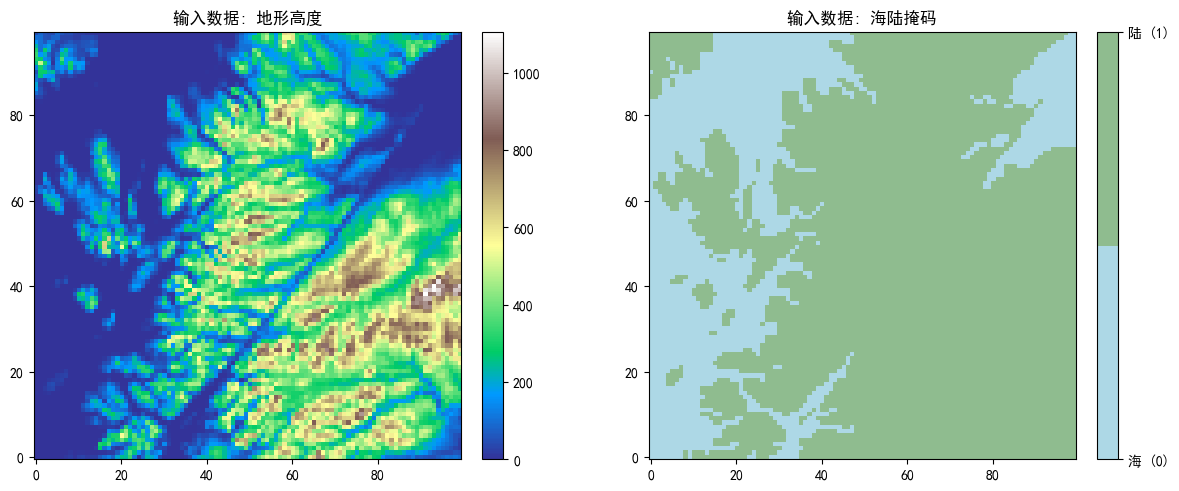

In [6]:
# 提取二维空间切片
orography_2d = orography.isel(member=0, level=0, time=0, dtime=0)
landmask_2d = landmask.isel(member=0, level=0, time=0, dtime=0)

plot_auxiliary_data("输入数据", orography_2d, landmask_2d)

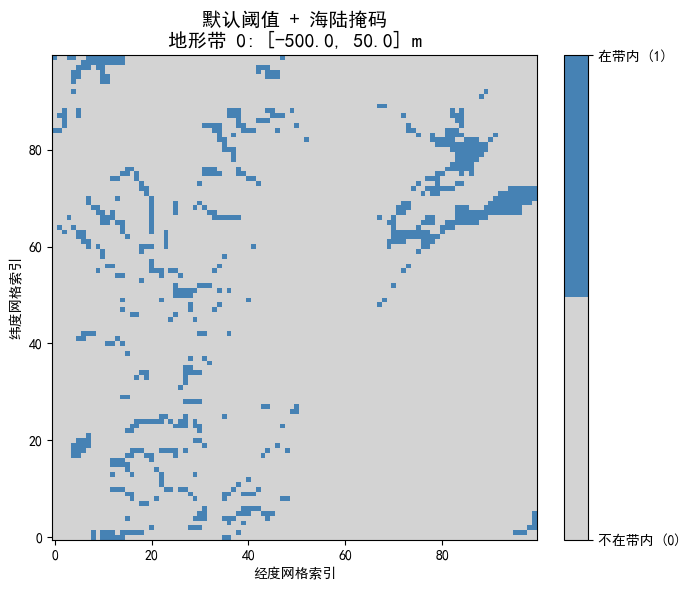

In [7]:
# 选择地形带
band_index = 0
lower_bound = THRESHOLDS_DICT["bounds"][band_index][0]
upper_bound = THRESHOLDS_DICT["bounds"][band_index][1]

# 提取二维数据
band_data = result_basic.isel(level=band_index, member=0, time=0, dtime=0).squeeze().values

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# 自定义离散色标：0 为浅灰色（不在带内），1 为蓝色（在带内）
cmap = ListedColormap(["lightgray", "steelblue"])

# 绘制地形带掩码
image = ax.imshow(
    band_data,
    cmap=cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="lower",
)

# 设置标题，包含地形带区域信息
title = f"默认阈值 + 海陆掩码\n地形带 {band_index}: [{lower_bound}, {upper_bound}] m"
ax.set_title(title, fontsize=14)

# 添加离散色标，只显示 0 和 1 两个刻度
cbar = plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
cbar.ax.set_yticklabels(["不在带内 (0)", "在带内 (1)"])

# 设置坐标轴标签
ax.set_xlabel("经度网格索引")
ax.set_ylabel("纬度网格索引")

plt.tight_layout()
plt.show()

## 5. 结果对比

### 5.1 默认阈值 + 海陆掩码

In [8]:
#地形带中心点值及上下界
describe_bands(result_basic)

band_index | center | lower | upper
         0 | -225.0 | -500.0 |   50.0
         1 |   75.0 |   50.0 |  100.0
         2 |  125.0 |  100.0 |  150.0
         3 |  175.0 |  150.0 |  200.0
         4 |  225.0 |  200.0 |  250.0
         5 |  275.0 |  250.0 |  300.0
         6 |  350.0 |  300.0 |  400.0
         7 |  450.0 |  400.0 |  500.0
         8 |  575.0 |  500.0 |  650.0
         9 |  725.0 |  650.0 |  800.0
        10 |  875.0 |  800.0 |  950.0
        11 | 3475.0 |  950.0 | 6000.0


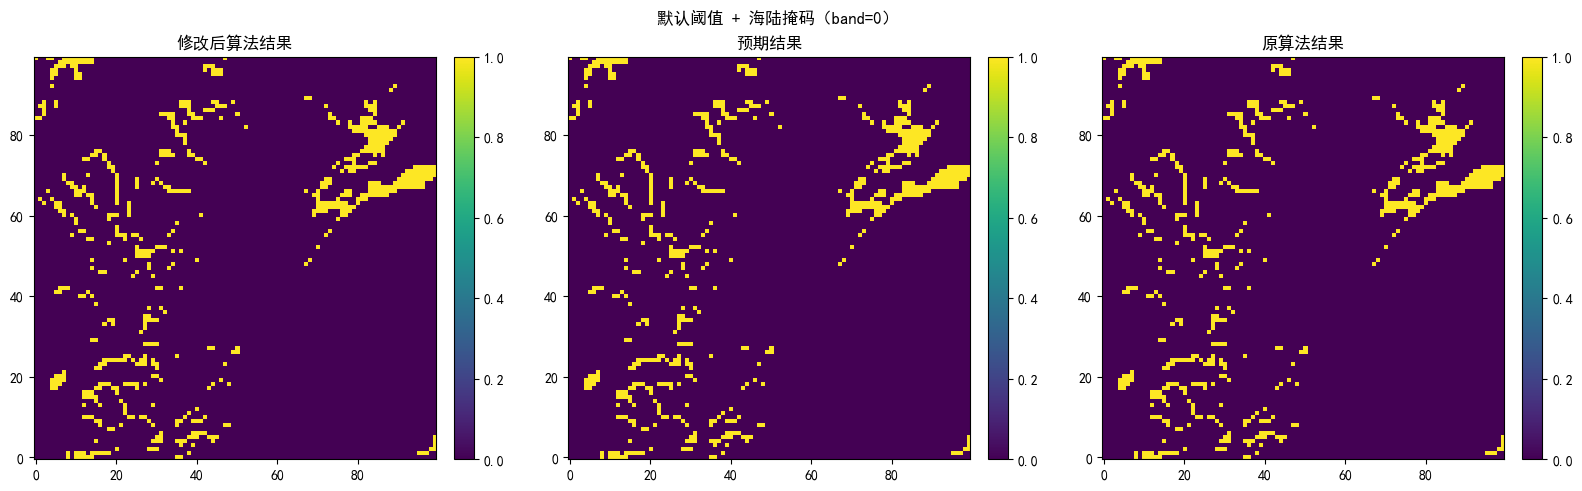

max_abs(modified-kgo): 0.0
max_abs(modified-original): 0.0


In [9]:
# 取第一层地形带对应的二维掩码切片进行对比
modified_2d = result_basic.isel(level=0).squeeze()
kgo_2d = kgo_basic.isel(topographic_zone=0).squeeze()
original_2d = original_basic.isel(topographic_zone=0).squeeze()

plot_result_triplet(
    f"默认阈值 + 海陆掩码（band=0）",
    modified_2d.values,
    kgo_2d.values,
    original_2d.values,
)

print("max_abs(modified-kgo):", float(np.max(np.abs(modified_2d.values - kgo_2d.values))))
print("max_abs(modified-original):", float(np.max(np.abs(modified_2d.values - original_2d.values))))

### 5.2 JSON 阈值 + 海陆掩码

In [10]:
#地形带中心点值及上下界
describe_bands(result_json)
print("JSON 阈值定义:")
print(json.dumps(json_thresholds, ensure_ascii=False, indent=2))

band_index | center | lower | upper
         0 | -250.0 | -500.0 |    0.0
         1 |   75.0 |    0.0 |  150.0
         2 |  175.0 |  150.0 |  200.0
         3 |  250.0 |  200.0 |  300.0
         4 |  450.0 |  300.0 |  600.0
JSON 阈值定义:
{
  "bounds": [
    [
      -500.0,
      0.0
    ],
    [
      0.0,
      150.0
    ],
    [
      150.0,
      200.0
    ],
    [
      200.0,
      300.0
    ],
    [
      300.0,
      600.0
    ]
  ],
  "units": "m"
}


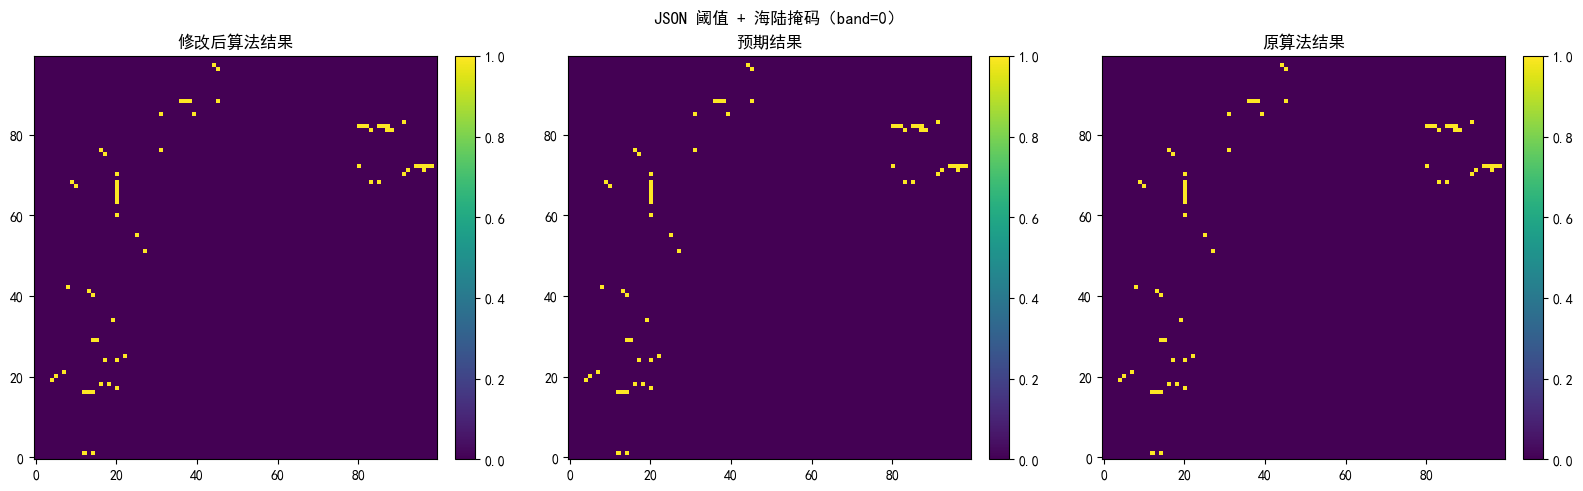

max_abs(modified-kgo): 0.0
max_abs(modified-original): 0.0


In [11]:
# 取第一层地形带对应的二维掩码切片进行对比
modified_json_2d = result_json.isel(level=0).squeeze()
kgo_json_2d = kgo_json.isel(topographic_zone=0).squeeze()
original_json_2d = original_json.isel(topographic_zone=0).squeeze()

plot_result_triplet(
    f"JSON 阈值 + 海陆掩码（band=0）",
    modified_json_2d.values,
    kgo_json_2d.values,
    original_json_2d.values,
)

print("max_abs(modified-kgo):", float(np.max(np.abs(modified_json_2d.values - kgo_json_2d.values))))
print("max_abs(modified-original):", float(np.max(np.abs(modified_json_2d.values - original_json_2d.values))))

### 5.3 默认阈值 + 无海陆掩码

In [12]:
#地形带中心点值及上下界
describe_bands(result_no_landmask)

band_index | center | lower | upper
         0 | -225.0 | -500.0 |   50.0
         1 |   75.0 |   50.0 |  100.0
         2 |  125.0 |  100.0 |  150.0
         3 |  175.0 |  150.0 |  200.0
         4 |  225.0 |  200.0 |  250.0
         5 |  275.0 |  250.0 |  300.0
         6 |  350.0 |  300.0 |  400.0
         7 |  450.0 |  400.0 |  500.0
         8 |  575.0 |  500.0 |  650.0
         9 |  725.0 |  650.0 |  800.0
        10 |  875.0 |  800.0 |  950.0
        11 | 3475.0 |  950.0 | 6000.0


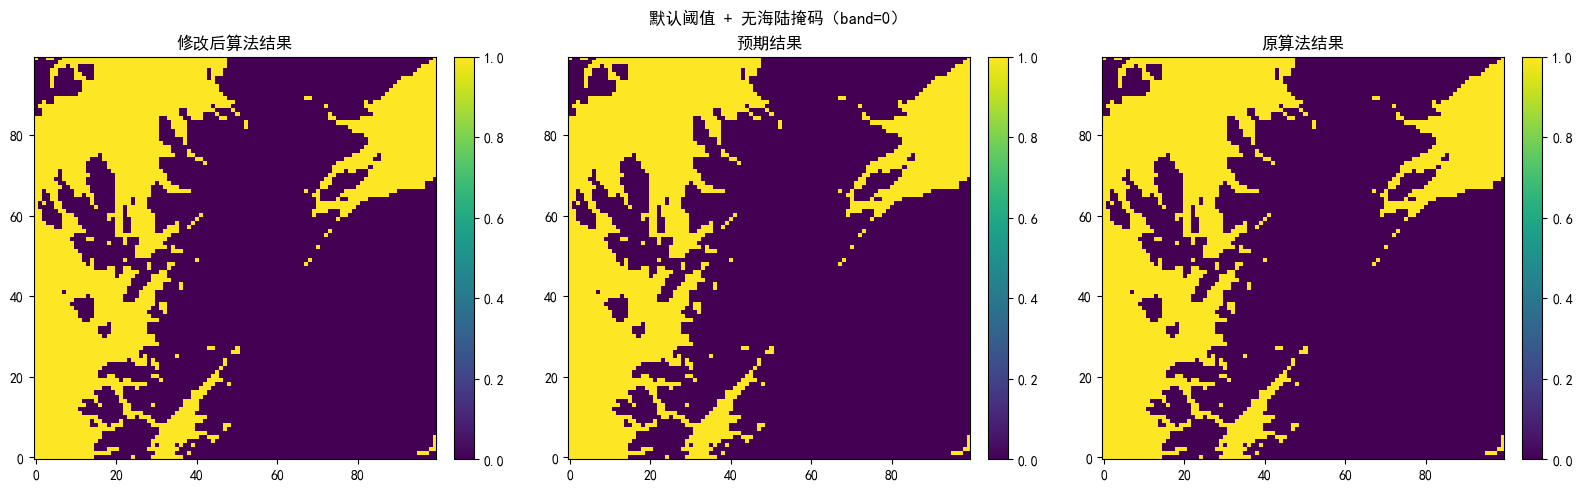

max_abs(modified-kgo): 0.0
max_abs(modified-original): 0.0


In [13]:
# 取第一层地形带对应的二维掩码切片进行对比
modified_no_landmask_2d = result_no_landmask.isel(level=0).squeeze()
kgo_no_landmask_2d = kgo_no_landmask.isel(topographic_zone=0).squeeze()
original_no_landmask_2d = original_no_landmask.isel(topographic_zone=0).squeeze()

plot_result_triplet(
    f"默认阈值 + 无海陆掩码（band=0）",
    modified_no_landmask_2d.values,
    kgo_no_landmask_2d.values,
    original_no_landmask_2d.values,
)

print("max_abs(modified-kgo):", float(np.max(np.abs(modified_no_landmask_2d.values - kgo_no_landmask_2d.values))))
print("max_abs(modified-original):", float(np.max(np.abs(modified_no_landmask_2d.values - original_no_landmask_2d.values))))

## 6. CLI示例及结果对比

### 6.1 generate_landmask_ancillary CLI示例



In [14]:
#暂未找到测试数据

### 6.2 generate_topography_bands_mask CLI结果对比

先在仓库根目录运行 CLI：

```powershell
python generate_ancillary/cli/dsc_generate_topography_bands_mask.py
```

然后执行下方代码单元，读取 CLI 输出、原CLI应用结果、KGO 进行对比。

In [15]:
# 读取 CLI 输出结果、原CLI应用结果、KGO 结果
CLI_OUTPUT_DIR = BASIC_DIR / "cli_outputs"
cli_result_path = CLI_OUTPUT_DIR / "cli_topography_bands_mask_result.nc"

cli_result = meb.read_griddata_from_nc(str(cli_result_path))
original_cli = load_primary_dataarray(BASIC_DIR / "original_from_json_bounds.nc")

# 全量三维分带结果对比（band, y, x）
cli_cube = np.asarray(cli_result.squeeze(drop=True).values)
kgo_cube = np.asarray(kgo_json.squeeze(drop=True).values)
original_cube = np.asarray(original_cli.squeeze(drop=True).values)

print("shape(cli):", cli_cube.shape)
print("shape(kgo):", kgo_cube.shape)
print("shape(original):", original_cube.shape)
print("max_abs(cli-kgo):", float(np.max(np.abs(cli_cube - kgo_cube))))
print("max_abs(cli-original):", float(np.max(np.abs(cli_cube - original_cube))))

shape(cli): (5, 100, 100)
shape(kgo): (5, 100, 100)
shape(original): (5, 100, 100)
max_abs(cli-kgo): 0.0
max_abs(cli-original): 0.0


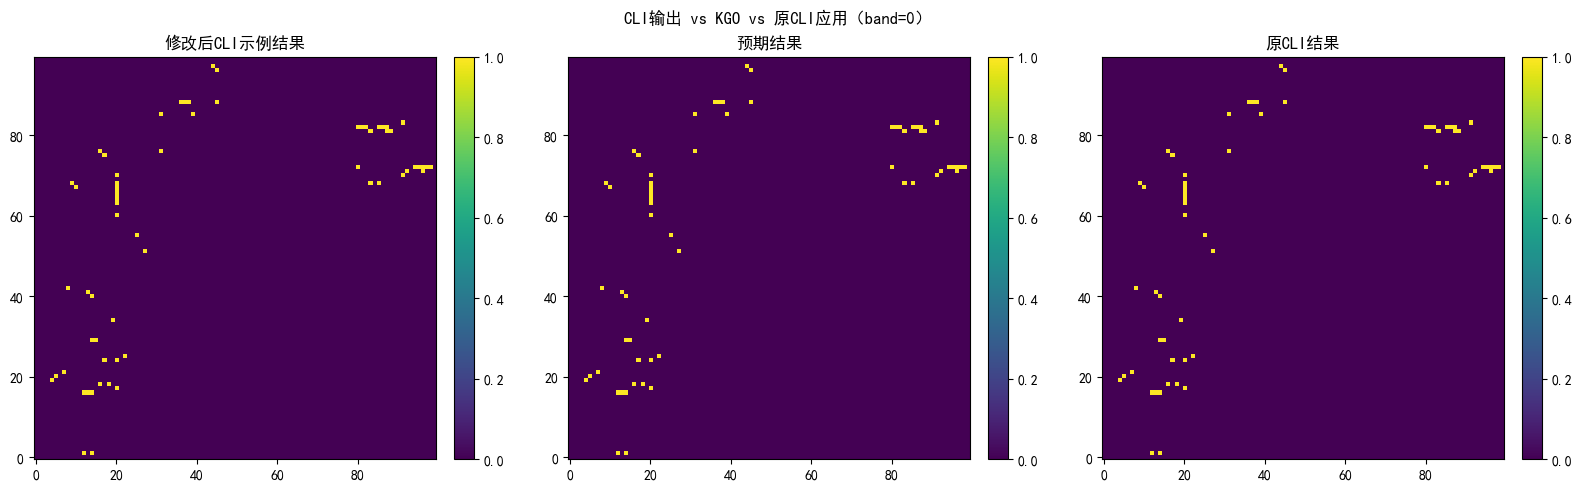

In [16]:
# 可视化：取第一个地形带做三联图
cli_2d = cli_result.isel(level=0).squeeze()
kgo_2d = kgo_json.isel(topographic_zone=0).squeeze()
original_2d = original_cli.isel(topographic_zone=0).squeeze()

vmin, vmax = common_limits(cli_2d.values, kgo_2d.values, original_2d.values)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
panels = [
    ("修改后CLI示例结果", cli_2d.values),
    ("预期结果", kgo_2d.values),
    ("原CLI结果", original_2d.values),
]
for ax, (panel_title, values) in zip(axes, panels):
    image = ax.imshow(
        values,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        origin="lower",
    )
    ax.set_title(panel_title)
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("CLI输出 vs KGO vs 原CLI应用（band=0）")
plt.show()